In [1]:
# gives you tools to: handle data, plot graphs, do ML work
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load dataset
df = pd.read_csv('/Users/sahasracherukupally/Desktop/House-Price-Prediction/data/train.csv')

In [4]:
# shows first 5 rows of datset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# total rows and colums
df.shape

(1460, 81)

In [6]:
# all column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
# column datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
#shows which columns are incomplete
df.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [9]:
#REMOVE columns with TOO MANY missing values
df = df.drop(columns=[
    "Alley",
    "PoolQC",
    "Fence",
    "MiscFeature",
    "FireplaceQu"
])

In [10]:
# for numerical columns handle the missing values with median
df = df.fillna(df.median(numeric_only=True))

In [11]:
# for categorical columns handle the missing values with mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
# after handling missing values checking how many missing values are there
df.isnull().sum().sum()

np.int64(0)

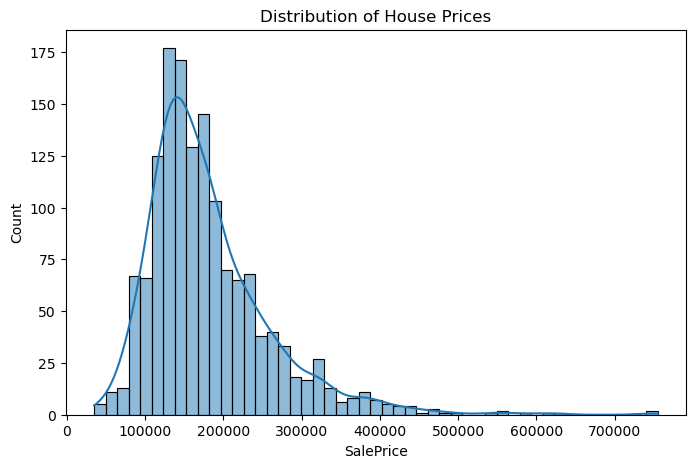

In [14]:
# Import visualization library
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)

# Add title
plt.title("Distribution of House Prices")

# Show plot
plt.show()

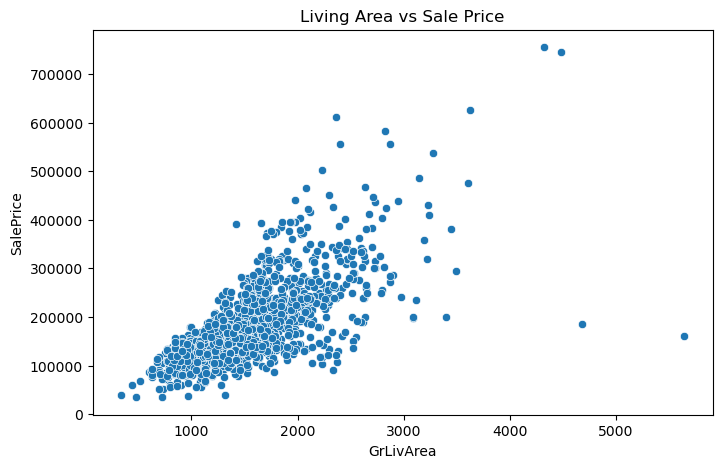

In [17]:
# Scatter plot to see relation between size and price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

# Title
plt.title("Living Area vs Sale Price")

plt.show()

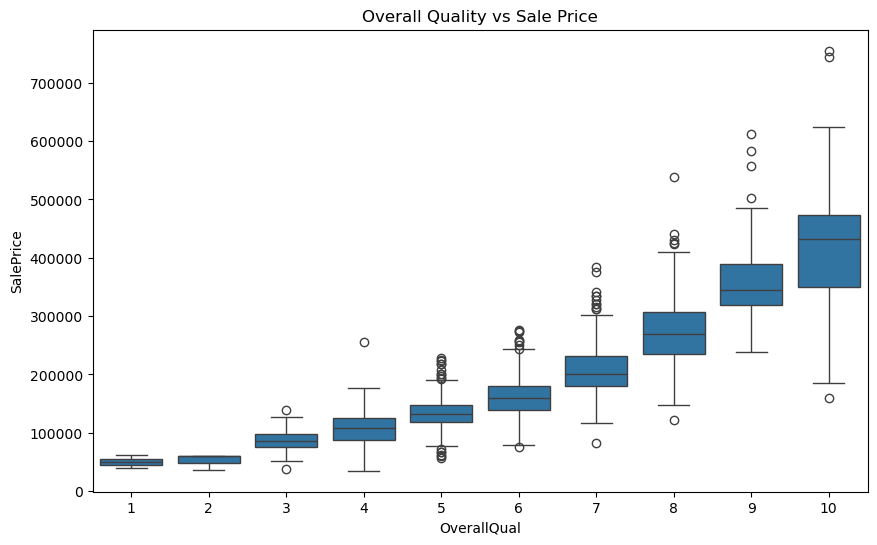

In [18]:
# Boxplot shows how quality affects price
plt.figure(figsize=(10,6))
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])

plt.title("Overall Quality vs Sale Price")

plt.show()

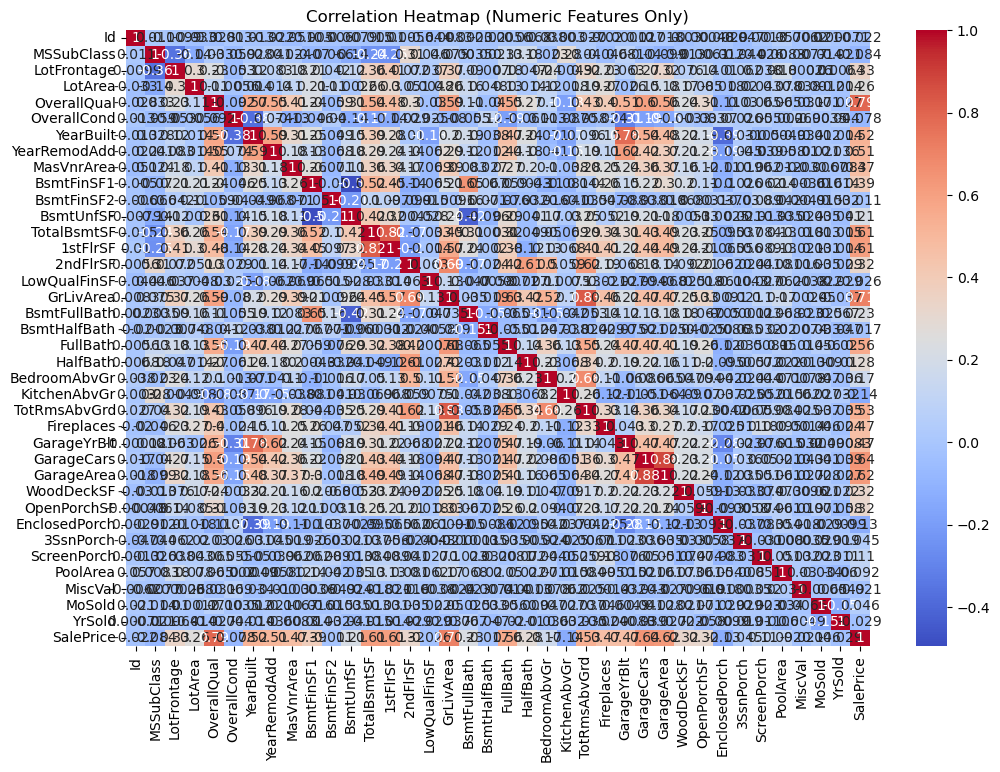

In [22]:
# Keep only numeric columns for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix shows relationship between variables (Helps find which features affect price most)
plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Numeric Features Only)")

plt.show()

In [23]:
# X = input features (everything except target)
X = df.drop("SalePrice", axis=1)

# y = target variable (what we predict)
y = df["SalePrice"]

In [24]:
# Convert text columns into numeric using One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Predict house prices
y_pred_lr = lr_model.predict(X_test)

In [28]:
# Evaluate linear Regression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("LINEAR REGRESSION RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

LINEAR REGRESSION RESULTS
MAE: 20347.913477913462
R2 Score: 0.6473288881008946


In [29]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor()

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [30]:
#Predictions
y_pred_rf = rf_model.predict(X_test)

In [31]:
# Evaluate Random Forest
print("RANDOM FOREST RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

RANDOM FOREST RESULTS
MAE: 17504.66219178082
R2 Score: 0.8972970243014537


In [32]:
# Print comparison of both models

print("=== LINEAR REGRESSION ===")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\n=== RANDOM FOREST ===")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

=== LINEAR REGRESSION ===
MAE: 20347.913477913462
R2 Score: 0.6473288881008946

=== RANDOM FOREST ===
MAE: 17504.66219178082
R2 Score: 0.8972970243014537


In [ ]:
##  Insights from Data

- Larger living area increases house price
- Overall quality of house strongly affects price
- Random Forest performs better than Linear Regression
- Features like GrLivArea, OverallQual are most important

In [33]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']